# Configuration and Imports
Importing necessary libraries.

In [1]:
# Config
import json
import librosa
import numpy as np
from pathlib import Path
from datetime import datetime
from typing import Union, Tuple
import joblib
import pandas as pd # Data analisys
from scripts.splitting import get_source_name, grouped_balanced_split

# Sklearn - model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Extraction Function Definitions
Defining functions to extract MFCC features and crawl the directory structure.

In [2]:

def extract_features(file_path: Union[str, Path], n_mfcc=13) -> np.ndarray:
    """Calculates the mean and standard deviation of MFCC coefficients
      to capture spectral characteristics and temporal dynamics of the audio segment.
    """

    y, sr = librosa.load(str(file_path), sr=16000)
    # Calculate MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    mfcc_mean = np.mean(mfcc.T, axis=0)
    mfcc_std = np.std(mfcc.T, axis=0)
    
    return np.hstack([mfcc_mean, mfcc_std])

def load_dataset(processed_path: Union[str, Path]) -> Tuple[np.ndarray, np.ndarray, dict, list]:
    """
    Crawls the processed data directory to extract features from all samples
      while automatically generating a numeric label mapping based on folder names.
    """
    X, y, file_paths = [], [], []
    label_to_name = {}
    processed_dir = Path(processed_path)
    
    for category_dir in processed_dir.iterdir():
        if not category_dir.is_dir():
            continue

        try:        
            label = int(category_dir.name.split('_')[0])
            clean_name = category_dir.name.split('_', 1)[1].replace('_', ' ').title()
            label_to_name[label] = clean_name
        except (ValueError, IndexError):
            continue

        for file_path in category_dir.glob("*.wav"):
            features = extract_features(file_path=file_path)
            X.append(features)
            y.append(label)
            file_paths.append(str(file_path))

    return np.array(X), np.array(y), label_to_name, file_paths

# Prepare Dataset

`load_dataset` runs MFCC extraction for every segment in `data/processed/`.

The split is **source-level and segment-balanced per class**: every original recording goes entirely to one of `train` / `val` / `test` (no leakage - `Leak check` must be all zeros) and each class is split into roughly **64% / 16% / 20%** of its **segments**, not just of its sources. This is necessary because source segment counts vary widely (one long ambient recording vs many short violence shouts), so plain source-level stratification leaves the per-class segment proportions in val/test very far from the train mix.

In [ ]:
# Load data
X, y, target_map, all_paths = load_dataset('../../data/processed')
target_names = [target_map[i] for i in sorted(target_map.keys())]

# Generate metadata for segments
meta = pd.DataFrame({
    "idx": range(len(all_paths)),
    "path": all_paths,
    "label": y,
})
meta["source"] = meta["path"].apply(get_source_name)

# Source level split
train_sources, val_sources, test_sources = grouped_balanced_split(
    meta,
    val_size=0.16,
    test_size=0.20,
    random_state=42,
)

# Filter data
train_mask = meta["source"].isin(train_sources).values
val_mask = meta["source"].isin(val_sources).values
test_mask = meta["source"].isin(test_sources).values

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

# For further data analysis
paths_train = meta.loc[train_mask, "path"].tolist()
paths_val = meta.loc[val_mask, "path"].tolist()
paths_test = meta.loc[test_mask, "path"].tolist()

print("Segments per split:")
print(f"  train: {len(y_train):>6}")
print(f"  val:   {len(y_val):>6}")
print(f"  test:  {len(y_test):>6}")

print("\nSegments per class per split (absolute):")
counts = pd.DataFrame({
    "train": pd.Series(y_train).value_counts(),
    "val":   pd.Series(y_val).value_counts(),
    "test":  pd.Series(y_test).value_counts(),
}).sort_index()
counts.index = [target_map[i] for i in counts.index]
print(counts)

print("\nClass proportions per split:")
proportions = pd.DataFrame({
    "train": pd.Series(y_train).value_counts(normalize=True),
    "val":   pd.Series(y_val).value_counts(normalize=True),
    "test":  pd.Series(y_test).value_counts(normalize=True),
}).sort_index().round(3)
proportions.index = [target_map[i] for i in proportions.index]
print(proportions)

print("\nPer-class share of segments going to each split:")
share = counts.div(counts.sum(axis=1), axis=0).round(3)
print(share)

# Sanity: no source should appear in more than one split
print("\nLeak check (all should be 0):")
print(f"  train ∩ val:  {len(train_sources & val_sources)}")
print(f"  train ∩ test: {len(train_sources & test_sources)}")
print(f"  val ∩ test:   {len(val_sources & test_sources)}")


Segments per split:
  train:  16666
  val:     4168
  test:    5210

Segments per class per split (absolute):
          train   val  test
Ambient    5040  1261  1576
Speech     5933  1484  1855
Violence   5693  1423  1779

Class proportions per split:
          train    val   test
Ambient   0.302  0.303  0.302
Speech    0.356  0.356  0.356
Violence  0.342  0.341  0.341

Per-class share of segments going to each split:
          train   val  test
Ambient    0.64  0.16   0.2
Speech     0.64  0.16   0.2
Violence   0.64  0.16   0.2

Leak check (all should be 0):
  train ∩ val:  0
  train ∩ test: 0
  val ∩ test:   0


# Hyperparameter Search on Validation

Each entry in `experiments` is one model configuration. Every config is trained on `train` and scored on `val`. The best config (by `SELECTION_METRIC`) is captured into `BEST_PARAMS` and used by the final cell below.

In [8]:
SELECTION_METRIC = "macro_f1"  # or "balanced_accuracy"

experiments = [
    {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": 30,   "min_samples_leaf": 2},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 1},
]

results = []
for params in experiments:
    rf = RandomForestClassifier(
        **params,
        random_state=7,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    y_val_pred = rf.predict(X_val)
    results.append({
        **params,
        "accuracy": accuracy_score(y_val, y_val_pred),
        "balanced_accuracy": balanced_accuracy_score(y_val, y_val_pred),
        "macro_f1": f1_score(y_val, y_val_pred, average="macro"),
        "weighted_f1": f1_score(y_val, y_val_pred, average="weighted"),
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(SELECTION_METRIC, ascending=False)
    .reset_index(drop=True)
)
print(f"Validation results (sorted by {SELECTION_METRIC}):")
print(results_df.to_string(index=True))

best_row = results_df.iloc[0]
PARAM_KEYS = ["n_estimators", "max_depth", "min_samples_leaf"]
BEST_PARAMS = {}
for k in PARAM_KEYS:
    val = best_row[k]
    # max_depth=None comes back as NaN through pandas - restore it
    BEST_PARAMS[k] = None if pd.isna(val) else int(val)

BEST_VAL_METRICS = {
    "accuracy": float(best_row["accuracy"]),
    "balanced_accuracy": float(best_row["balanced_accuracy"]),
    "macro_f1": float(best_row["macro_f1"]),
    "weighted_f1": float(best_row["weighted_f1"]),
}

print(f"\nBEST_PARAMS (by {SELECTION_METRIC}): {BEST_PARAMS}")
print(f"BEST_VAL_METRICS: {BEST_VAL_METRICS}")

Validation results (sorted by macro_f1):
   n_estimators  max_depth  min_samples_leaf  accuracy  balanced_accuracy  macro_f1  weighted_f1
0           200        NaN                 1  0.784789           0.795476  0.775706     0.768893
1           300        NaN                 1  0.783829           0.794547  0.774539     0.767674
2           100        NaN                 1  0.783589           0.794284  0.774483     0.767636
3           200       30.0                 2  0.780710           0.791530  0.771712     0.764580

BEST_PARAMS (by macro_f1): {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1}
BEST_VAL_METRICS: {'accuracy': 0.7847888675623801, 'balanced_accuracy': 0.7954758041321178, 'macro_f1': 0.7757057573103764, 'weighted_f1': 0.7688932985861686}


# Final Training & Test Evaluation

Re-trains the chosen configuration on `train + val` (more data -> typically a slightly stronger model) and evaluates **once** on the held-out `test` set.

In [9]:
# Re-train the chosen configuration on (train + val) - more data, identical hyperparameters
X_trainval = np.concatenate([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

model = RandomForestClassifier(
    **BEST_PARAMS,
    random_state=7,
    n_jobs=-1,
)
model.fit(X_trainval, y_trainval)

# Final predictions on the held-out TEST set
y_test_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_test_pred)
balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average='macro')
weighted_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"Final params: {BEST_PARAMS}")
print(f"Accuracy:          {acc * 100:.2f}%")
print(f"Balanced accuracy: {balanced_acc * 100:.2f}%")
print(f"Macro F1:          {macro_f1:.4f}")
print(f"Weighted F1:       {weighted_f1:.4f}")
print(classification_report(y_test, y_test_pred, target_names=target_names))

Final params: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1}
Accuracy:          79.58%
Balanced accuracy: 79.83%
Macro F1:          0.7969
Weighted F1:       0.7956
              precision    recall  f1-score   support

     Ambient       0.79      0.84      0.81      1576
      Speech       0.76      0.74      0.75      1855
    Violence       0.84      0.81      0.82      1779

    accuracy                           0.80      5210
   macro avg       0.80      0.80      0.80      5210
weighted avg       0.80      0.80      0.80      5210



# Versioning and Serialization
Creating a new version folder and saving the model, reports and confusion matrix.

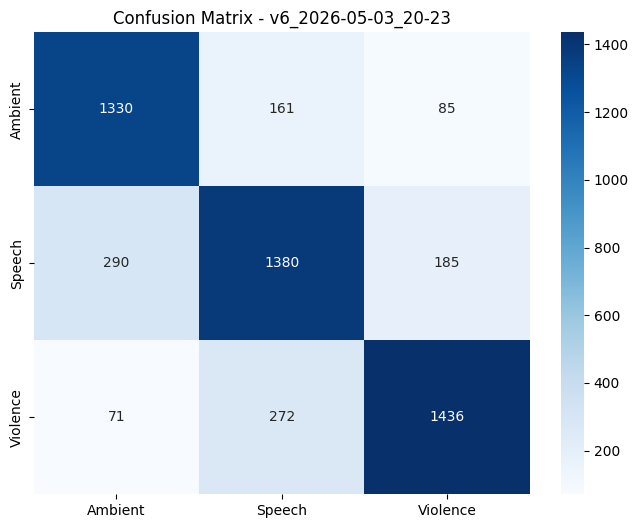

In [ ]:
def get_next_version(base_path: Path) -> str:
    base_path.mkdir(parents=True, exist_ok=True)
    existing = [d.name for d in base_path.iterdir() if d.is_dir() and d.name.startswith('v')]
    version_numbers = []
    for v in existing:
        try:
            num = int(v.split('_')[0][1:])
            version_numbers.append(num)
        except ValueError:
            continue
    
    next_num = max(version_numbers, default=0) + 1
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")

    return f"v{next_num}_{timestamp}"

# Set versioning paths
BASE_DIR_MODEL = Path('../../models/rf')
BASE_DIR_REPORT = Path('../../reports/rf')
CURRENT_VERSION = get_next_version(BASE_DIR_MODEL)
MODEL_PATH = BASE_DIR_MODEL / CURRENT_VERSION
REPORT_PATH = BASE_DIR_REPORT / CURRENT_VERSION
MODEL_PATH.mkdir(parents=True, exist_ok=True)
REPORT_PATH.mkdir(parents=True, exist_ok=True)

# Save model & name map
joblib.dump(model, MODEL_PATH / 'rf_model.pkl')
joblib.dump(target_map, MODEL_PATH / 'target_map.pkl')

# Save confusion matrix img (computed on the held-out TEST set)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f"Confusion Matrix - {CURRENT_VERSION}")
plt.savefig(REPORT_PATH / 'confusion_matrix.png')
plt.show()

# Save detailed errors to csv
analysis_df = pd.DataFrame({
    'file_path': paths_test,
    'true_label': [target_map[i] for i in y_test],
    'predicted_label': [target_map[i] for i in y_test_pred]
})
errors = analysis_df[analysis_df['true_label'] != analysis_df['predicted_label']]
errors.to_csv(REPORT_PATH / 'classification_errors.csv', index=False)

# Persist a self-contained record of this run: chosen hyperparameters,
# validation results that drove the choice, and final test metrics
report_dict = classification_report(
    y_test, y_test_pred, target_names=target_names, output_dict=True, zero_division=0
)
metrics_payload = {
    'version': CURRENT_VERSION,
    'best_params': BEST_PARAMS,
    'selection_metric': SELECTION_METRIC,
    'val_metrics': BEST_VAL_METRICS,
    'n_train_segments': int(len(y_train)),
    'n_val_segments': int(len(y_val)),
    'n_test_segments': int(len(y_test)),
    'train_class_proportions': pd.Series(y_train).value_counts(normalize=True).sort_index().round(4).to_dict(),
    'val_class_proportions': pd.Series(y_val).value_counts(normalize=True).sort_index().round(4).to_dict(),
    'test_class_proportions': pd.Series(y_test).value_counts(normalize=True).sort_index().round(4).to_dict(),
    'test_metrics': {
        'accuracy': float(acc),
        'balanced_accuracy': float(balanced_acc),
        'macro_f1': float(macro_f1),
        'weighted_f1': float(weighted_f1),
    },
    'classification_report_test': report_dict,
}
with open(REPORT_PATH / 'metrics.json', 'w') as f:
    json.dump(metrics_payload, f, indent=2)

# Save info about latest version to .txt
with open('../../latest_version_rf.txt', 'w') as f:
    f.write(CURRENT_VERSION)